<a href="https://colab.research.google.com/github/kataamb/notebooks_data_analysis/blob/main/kaggle_automobile_prices/kaggle_automobile_dataset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Исследование датасета, описывающего продажи машин. Цель - помочь покупателям  и продавцам понять, какие характеристики и каким именно образом влияют на стоимость машины

Ссылка на датасет в kaggle: https://www.kaggle.com/datasets/deeplumiere/automobile-market-analytics-dataset


Информация о полях датасета:

|Feature |	Description|
| --- | --- |
Make |	Vehicle manufacturer (Toyota, Honda, BMW, Mercedes-Benz, Audi, etc.)
Model |	Vehicle model name
Year |	Manufacturing year
Fuel_Type	Fuel | category (Petrol, Diesel, Hybrid, Electric)
Transmission	| Manual or Automatic transmission
Engine_Size |	Engine  displacement in liters
Mileage	Total | distance driven (miles)
Horsepower	| Engine power output
Torque |	Engine torque
Owners |	Number of previous owners
Accident_History |	Previous accident record (0 = No, 1 = Yes)
Service_History	| Maintenance history (Full Service, Partial Service, No Service)
Color	| Exterior color
Body_Type |	Sedan, SUV, Truck, Coupe, Hatchback
Drivetrain |	FWD, AWD, RWD, or 4WD
Fuel_Efficiency |	Estimated fuel economy (MPG/MPGe)
Location	| Vehicle location (US state abbreviation)
Selling_Price	| Estimated resale price (Target Variable)


In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = '/content/drive/MyDrive/ColabDatasets/automobile_dataset.csv'


In [48]:
import pandas as pd
import seaborn as sns

In [49]:
import matplotlib.pyplot as plt

In [51]:
import numpy as np

#1. Изучение характеристик датасета



1.1 Загрузка датасета

In [29]:
df = pd.read_csv(path)
df.head(10)

,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
0,Mercedes-Benz,GLE,2024,Petrol,Automatic,2.3,100,186.0,196.0,1,0.0,NaN,Silver,SUV,AWD,30.0,IL,64140
1,Hyundai,Tucson,2008,Petrol,Automatic,2.3,387035,189.0,190.0,4,0.0,NaN,Blue,SUV,FWD,35.0,FL,500
2,Volkswagen,Golf,2021,Hybrid,NaN,1.9,46054,158.0,153.0,1,0.0,Partial Service,Gray,Hatchback,AWD,43.0,NY,16429
3,Chevrolet,Tahoe,2005,Petrol,NaN,2.2,141302,169.0,165.0,5,1.0,No Service,Blue,SUV,AWD,NaN,FL,2199
4,Toyota,Camry,2022,Petrol,Automatic,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,21792
5,Chevrolet,Equinox,2008,Petrol,NaN,2.7,60654,212.0,207.0,3,0.0,NaN,Blue,SUV,AWD,25.0,TX,3421
6,Nissan,Sentra,2022,Petrol,Automatic,2.2,7444,NaN,180.0,1,0.0,Full Service,Gray,Sedan,AWD,34.0,IL,17145
7,Mercedes-Benz,C-Class,2022,Petrol,Automatic,2.3,32133,180.0,162.0,1,0.0,Partial Service,Green,Sedan,FWD,35.0,NY,31416
8,BMW,X3,2023,Petrol,Automatic,NaN,1553,203.0,179.0,1,0.0,Full Service,NaN,SUV,AWD,25.0,FL,43914
9,Honda,Pilot,2020,Hybrid,Automatic,2.1,12494,178.0,168.0,1,NaN,No Service,Blue,SUV,FWD,44.0,NC,22311


1.2 Информация о полях датасета

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Make              5500 non-null   object 
 1   Model             5500 non-null   object 
 2   Year              5500 non-null   int64  
 3   Fuel_Type         5500 non-null   object 
 4   Transmission      4673 non-null   object 
 5   Engine_Size       4656 non-null   float64
 6   Mileage           5500 non-null   int64  
 7   Horsepower        4700 non-null   float64
 8   Torque            4701 non-null   float64
 9   Owners            5500 non-null   int64  
 10  Accident_History  4688 non-null   float64
 11  Service_History   4645 non-null   object 
 12  Color             4697 non-null   object 
 13  Body_Type         5500 non-null   object 
 14  Drivetrain        5500 non-null   object 
 15  Fuel_Efficiency   4706 non-null   float64
 16  Location          4718 non-null   object 


In [ ]:
df.describe()

,Year,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Fuel_Efficiency,Selling_Price
count,5500.000000,4656.000000,5500.000000,4700.000000,4701.000000,5500.000000,4688.000000,4706.000000,5500.000000
mean,2014.494000,2.450623,114529.481636,198.236596,189.014678,2.464000,0.408063,34.179771,12319.873636
std,5.789745,0.843913,91858.943421,55.678165,56.631309,1.280022,0.491527,15.085473,12658.478862
min,2005.000000,0.000000,100.000000,97.000000,77.000000,1.000000,0.000000,10.000000,500.000000
25%,2009.000000,2.000000,39112.000000,160.000000,151.000000,1.000000,0.000000,27.000000,1304.750000
50%,2014.000000,2.400000,96926.500000,187.000000,178.000000,2.000000,0.000000,32.000000,8586.000000
75%,2020.000000,3.000000,172757.500000,231.000000,219.000000,3.000000,1.000000,37.000000,19097.500000
max,2024.000000,5.700000,536731.000000,434.000000,443.000000,5.000000,1.000000,141.000000,86692.000000


1.3 Анализ количества Nan

In [ ]:
df.isnull().sum() / df.count() * 100

,0
Make,0.000000
Model,0.000000
Year,0.000000
Fuel_Type,0.000000
Transmission,17.697411
Engine_Size,18.127148
Mileage,0.000000
Horsepower,17.021277
Torque,16.996384
Owners,0.000000


In [ ]:
df.isnull().mean() * 100


,0
Make,0.000000
Model,0.000000
Year,0.000000
Fuel_Type,0.000000
Transmission,15.036364
Engine_Size,15.345455
Mileage,0.000000
Horsepower,14.545455
Torque,14.527273
Owners,0.000000


<BarContainer object of 18 artists>

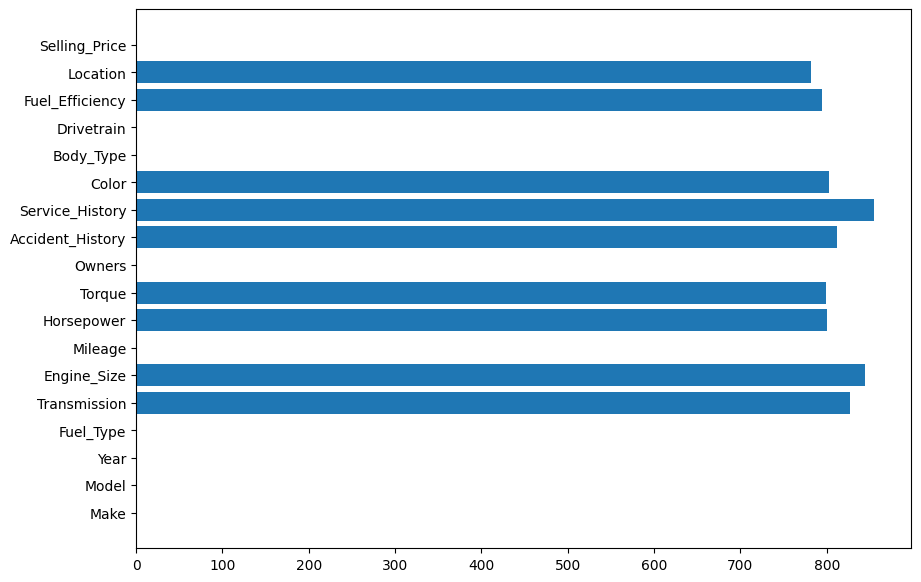

In [8]:
data = df.isna().sum()

plt.figure(figsize=(10,7))

plt.barh(data.index, data.values)

<Axes: >

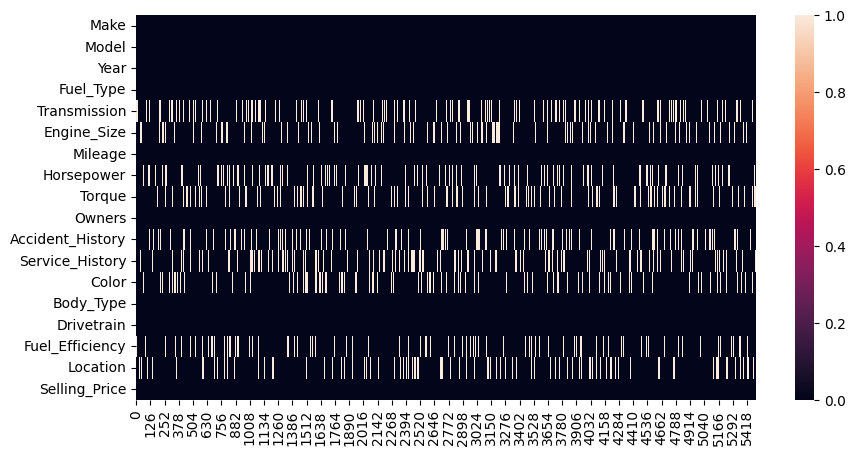

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isna().transpose())

Пропусков много, мы не можем "выкинуть" Nan-значения

##1.4 Преобразование датасета. Создание новых признаков

In [30]:
from datetime import datetime

In [31]:
df['Age_Auto'] = datetime.now().year - df['Year']

In [32]:
df.drop(columns=['Year'], inplace = True)

In [12]:
df

,Make,Model,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price,Age_Auto
0,Mercedes-Benz,GLE,Petrol,Automatic,2.3,100,186.0,196.0,1,0.0,NaN,Silver,SUV,AWD,30.0,IL,64140,2
1,Hyundai,Tucson,Petrol,Automatic,2.3,387035,189.0,190.0,4,0.0,NaN,Blue,SUV,FWD,35.0,FL,500,18
2,Volkswagen,Golf,Hybrid,NaN,1.9,46054,158.0,153.0,1,0.0,Partial Service,Gray,Hatchback,AWD,43.0,NY,16429,5
3,Chevrolet,Tahoe,Petrol,NaN,2.2,141302,169.0,165.0,5,1.0,No Service,Blue,SUV,AWD,NaN,FL,2199,21
4,Toyota,Camry,Petrol,Automatic,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,21792,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,Volkswagen,Tiguan,Petrol,Automatic,NaN,29506,161.0,NaN,1,0.0,Partial Service,Black,SUV,AWD,33.0,GA,20333,4
5496,Nissan,Pathfinder,Petrol,Automatic,3.1,287332,243.0,227.0,5,1.0,No Service,Gray,SUV,AWD,NaN,NY,500,20
5497,BMW,X3,Petrol,Automatic,2.2,95961,171.0,152.0,2,1.0,No Service,Blue,SUV,AWD,32.0,MI,9882,13
5498,Volkswagen,Golf,Hybrid,Automatic,1.5,56643,135.0,125.0,2,1.0,No Service,White,Hatchback,FWD,57.0,NY,10474,6


Два признака, Torque и Horsepower связаны линейным соотношеннием: Horsepower = Torque * Engine_Speed/5252 (Engine_Speed - обороты двигателя). Поэтому нужно выделить Engine_Speed и убрать лошадиные силы.

In [33]:
df['Engine_Speed'] = df.Horsepower / df.Torque *5252

In [34]:
df.drop(columns=['Horsepower'],inplace=True)

В датасете есть числовые и категориальные признаки. Выделим их, а также столбец целевой переменной - цену (Selling_Price)

In [35]:
categorial_features = ['Make', 'Model', 'Fuel_Type', 'Transmission', 'Service_History', 'Color', 'Body_Type', 'Drivetrain', 'Location']
number_features = ['Age_Auto', 'Engine_Size', 'Mileage', 'Engine_Speed', 'Torque', 'Owners', 'Accident_History', 'Fuel_Efficiency']
target_feature = 'Selling_Price'

#2 Влияние признаков на целевую переменную

##2.1 Влияние числовых признаков

Рассмотрим корелляцию числовых признаков и и цены (целевой переменной). Корелляция покажет наличие или отсутствие линейной зависимости между данными

<Axes: >

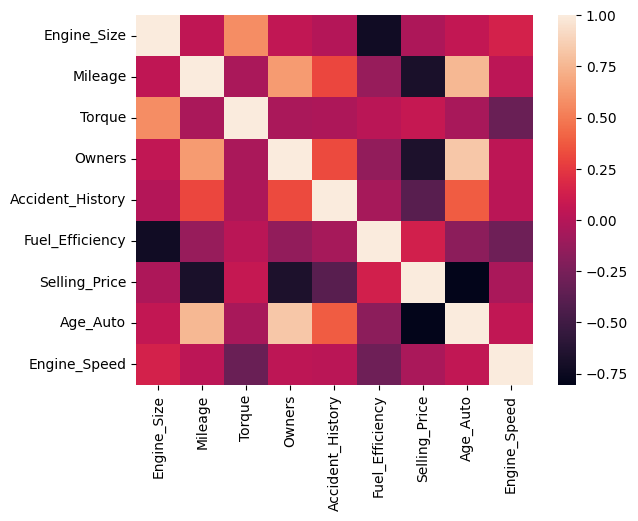

In [36]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix)

In [37]:
corr_matrix

,Engine_Size,Mileage,Torque,Owners,Accident_History,Fuel_Efficiency,Selling_Price,Age_Auto,Engine_Speed
Engine_Size,1.000000,0.041886,0.569936,0.051901,-0.001325,-0.725594,-0.030062,0.061126,0.144060
Mileage,0.041886,1.000000,-0.045893,0.628654,0.302310,-0.127446,-0.682883,0.754184,0.028208
Torque,0.569936,-0.045893,1.000000,-0.046096,-0.036168,0.023809,0.075116,-0.056140,-0.314749
Owners,0.051901,0.628654,-0.046096,1.000000,0.316544,-0.147069,-0.669046,0.830702,0.034180
Accident_History,-0.001325,0.302310,-0.036168,0.316544,1.000000,-0.057804,-0.391484,0.383245,0.022362
Fuel_Efficiency,-0.725594,-0.127446,0.023809,-0.147069,-0.057804,1.000000,0.128593,-0.163573,-0.293745
Selling_Price,-0.030062,-0.682883,0.075116,-0.669046,-0.391484,0.128593,1.000000,-0.804933,-0.048329
Age_Auto,0.061126,0.754184,-0.056140,0.830702,0.383245,-0.163573,-0.804933,1.000000,0.049316
Engine_Speed,0.144060,0.028208,-0.314749,0.034180,0.022362,-0.293745,-0.048329,0.049316,1.000000


,Selling_Price
Age_Auto,-0.804933
Engine_Size,-0.030062
Mileage,-0.682883
Engine_Speed,-0.048329
Torque,0.075116
Owners,-0.669046
Accident_History,-0.391484
Fuel_Efficiency,0.128593


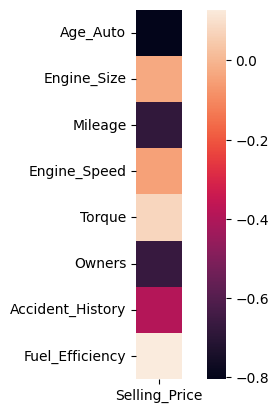

In [41]:
correlation_price = df[number_features].corrwith(df[target_feature]).to_frame(target_feature)
#f, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(correlation_price, square=True)
correlation_price

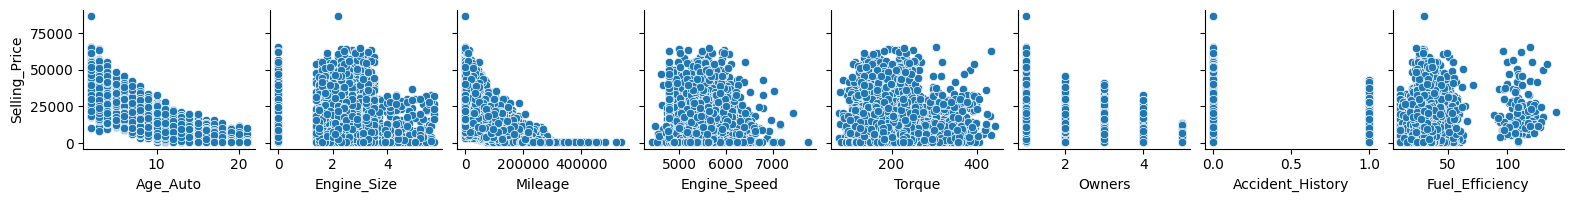

In [40]:
sns.pairplot(pd.concat([df[number_features], df[target_feature]]), x_vars=number_features, y_vars = target_feature, height = 2 ,kind ='scatter',diag_kind='kde')
plt.show()

По некоторым полям визуально тяжело определить, имеет ли выраженное влияние признак на цену или нет

---



Поэтому посчитаем для числовых признаков корелляцию (получим в числах).
Будем считать, что:

|r| >= 0.7  => сильная связь

0.3 <= |r| < 0.7 => средняя связь

0.1 <= |r| < 0.3 => слабая связь

|r| < 0.1 => связи практически нет

In [ ]:
df[number_features].corrwith(df[target_feature]).sort_values(ascending=False)

,0
Fuel_Efficiency,0.128593
Torque,0.075116
Horsepower,0.064324
Engine_Size,-0.030062
Accident_History,-0.391484
Owners,-0.669046
Mileage,-0.682883
Age_Auto,-0.804933


Предварительно можно сделать выводы, что цена зависит от возраста авто, размера двигателя, пробега, количества владельцев, наличие аварий. Причем с ростом возрастом авто, с увеличением пробега цена падает, с увеличением количества владельцев цена падает, с наличинем аварий цена падает

#2.2 Влияние категориальных

Рассмотрим влияние категориальных признаков на цену

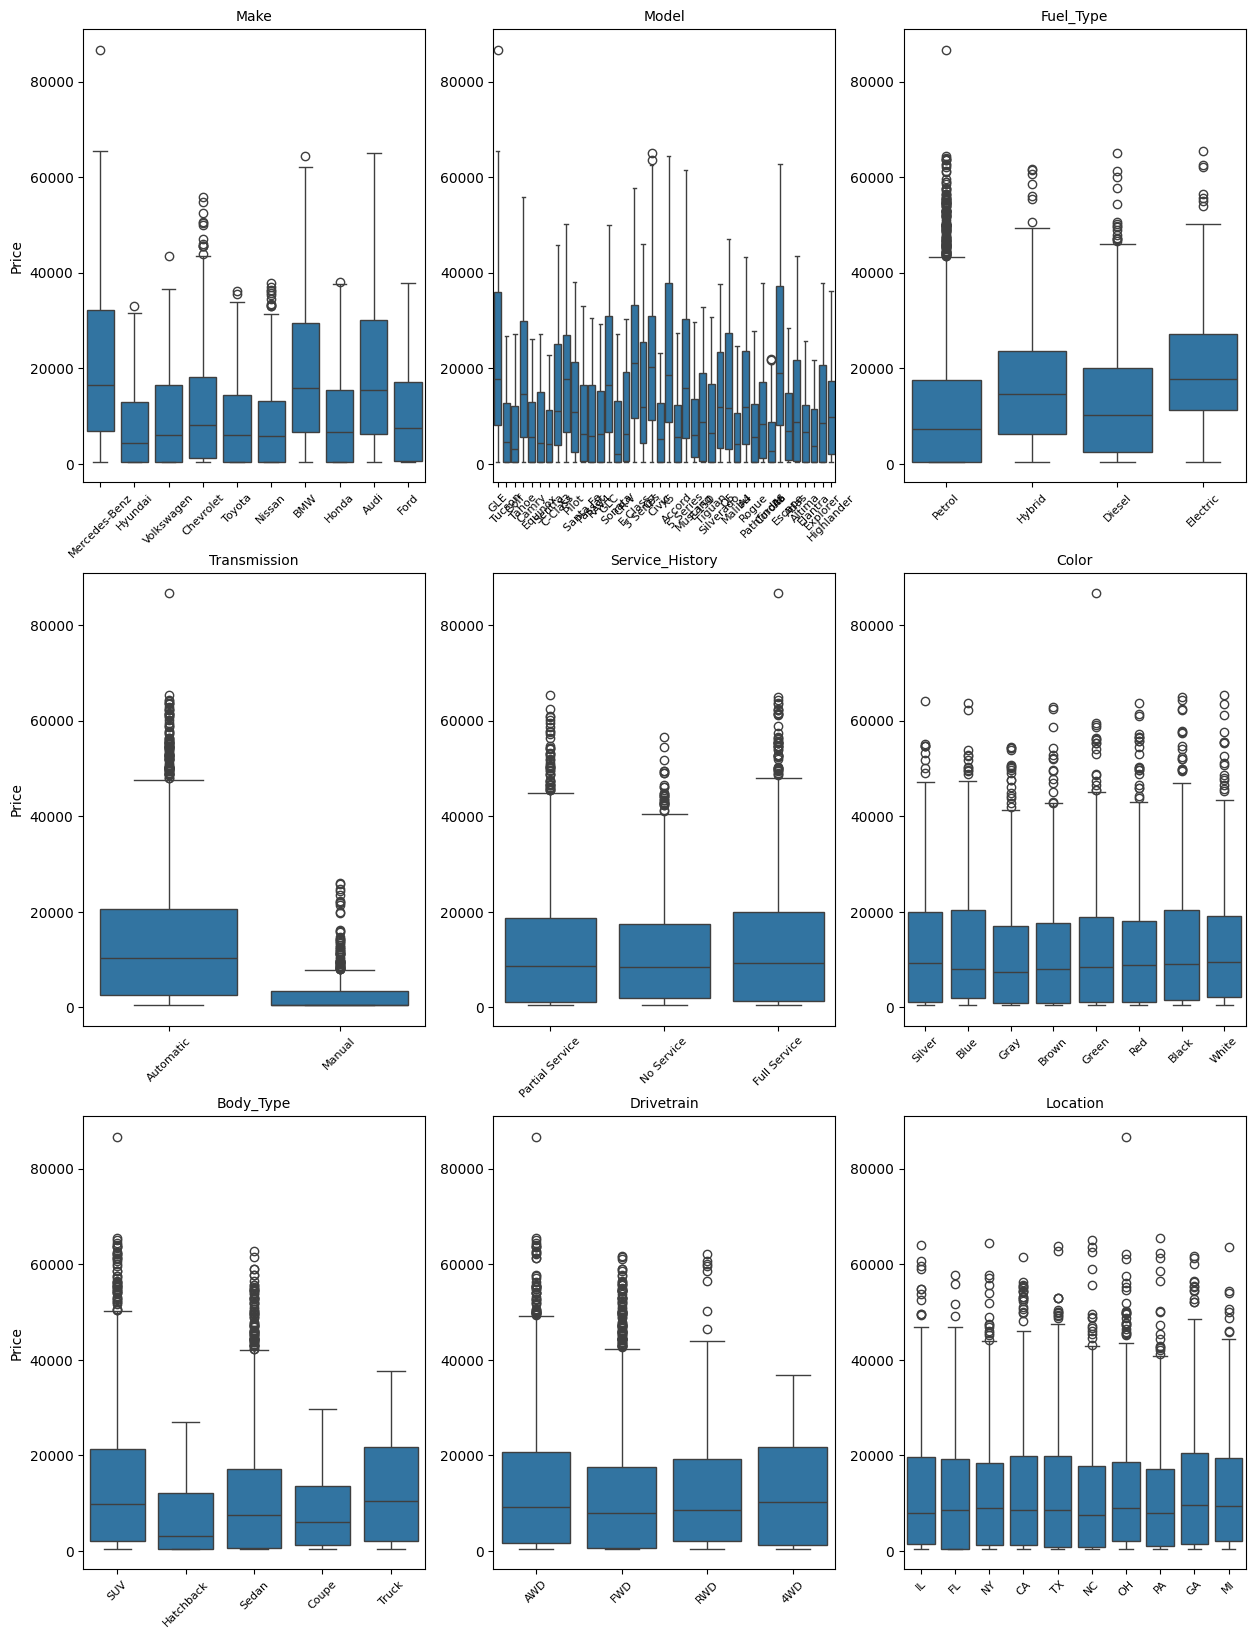

In [ ]:
cat_cols = categorial_features
# Создаём сетку 3x3
fig, axes = plt.subplots(3, 3, figsize=(15, 20))  # 3 строки, 3 колонки
axes = axes.flatten()  # превращаем в одномерный массив для удобства

# Рисуем графики
for i, col in enumerate(cat_cols):
    sns.boxplot(x=df[col], y=df['Selling_Price'], ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].set_ylabel('Price' if i % 3 == 0 else '')  # убираем повторяющиеся подписи
    axes[i].set_xlabel('')

Для некоторых категорий тяжело оценить визуально, влияет ли признак на цену или нет


In [ ]:

model_categories = df.groupby('Model')['Selling_Price'].mean().sort_values(ascending=False)

<BarContainer object of 40 artists>

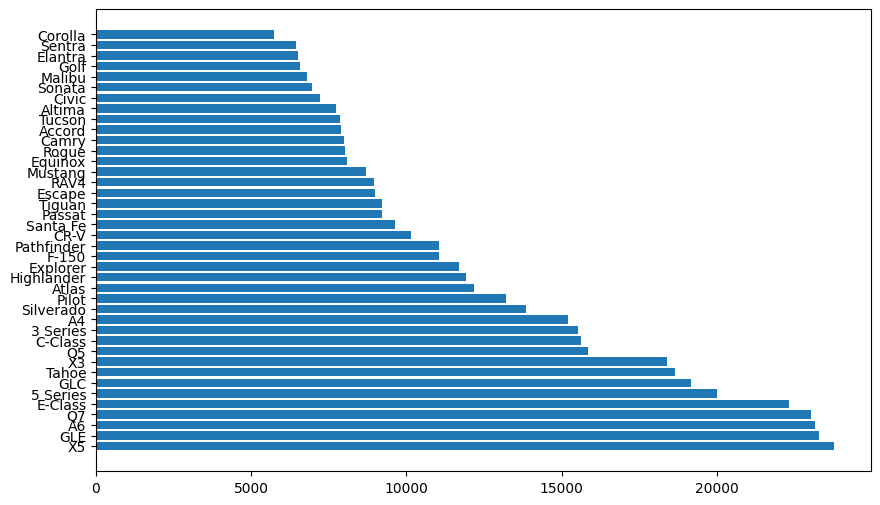

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(model_categories.index, model_categories.values)


<BarContainer object of 8 artists>

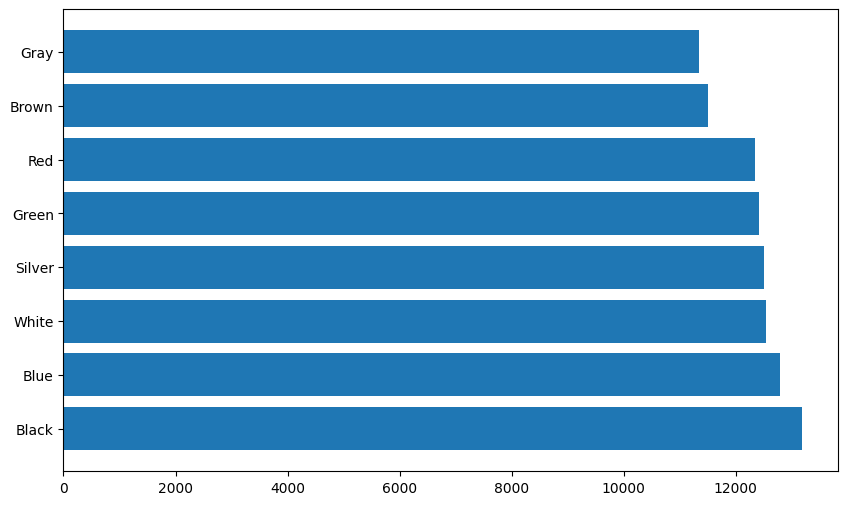

In [ ]:

color_categories = df.groupby('Color')['Selling_Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(color_categories.index, color_categories.values)


<BarContainer object of 4 artists>

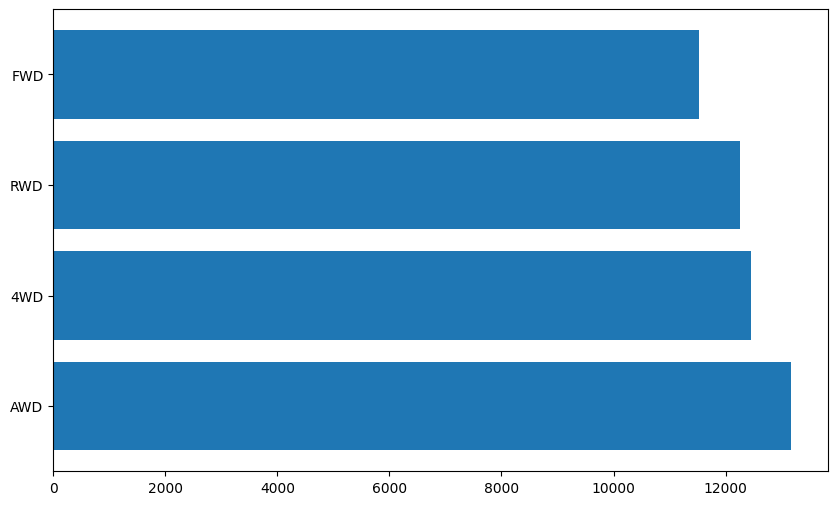

In [ ]:
drivetrain_categories = df.groupby('Drivetrain')['Selling_Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(drivetrain_categories.index, drivetrain_categories.values)


<BarContainer object of 10 artists>

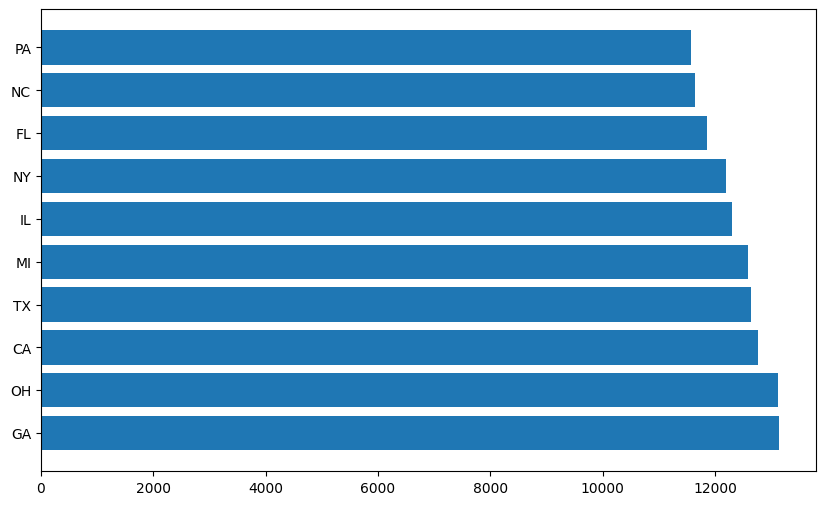

In [ ]:
location_categories = df.groupby('Location')['Selling_Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(location_categories.index, location_categories.values)

#df.groupby('Transmission')['Selling_Price'].mean().sort_values(ascending=False)


Предварительно можно сделать вывод, что на цену влияет тип топлива, коробка передач, истории сервиса, марка машины. Незначительно на цену влияют цвет и локация, трансмиссия (drivetrain)

#3 Заполнение NAN

У числовых заменим пропуски медианой,  у категориальных - модой

Для более точных значений, вычислим для каждой марки машины (моду и медиану)

Для числовых

In [42]:
medians = df.groupby('Model')[number_features].median()


In [43]:
df[number_features]= df[number_features].fillna(
    df.groupby('Model')[number_features].transform('median')
)

In [ ]:
df

,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price,Age_Auto
0,Mercedes-Benz,GLE,2024,Petrol,Automatic,2.3,100,186.0,196.0,1,0.0,NaN,Silver,SUV,AWD,30.0,IL,64140,2
1,Hyundai,Tucson,2008,Petrol,Automatic,2.3,387035,189.0,190.0,4,0.0,NaN,Blue,SUV,FWD,35.0,FL,500,18
2,Volkswagen,Golf,2021,Hybrid,NaN,1.9,46054,158.0,153.0,1,0.0,Partial Service,Gray,Hatchback,AWD,43.0,NY,16429,5
3,Chevrolet,Tahoe,2005,Petrol,NaN,2.2,141302,169.0,165.0,5,1.0,No Service,Blue,SUV,AWD,30.0,FL,2199,21
4,Toyota,Camry,2022,Petrol,Automatic,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,21792,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,Volkswagen,Tiguan,2022,Petrol,Automatic,2.8,29506,161.0,208.0,1,0.0,Partial Service,Black,SUV,AWD,33.0,GA,20333,4
5496,Nissan,Pathfinder,2006,Petrol,Automatic,3.1,287332,243.0,227.0,5,1.0,No Service,Gray,SUV,AWD,30.0,NY,500,20
5497,BMW,X3,2013,Petrol,Automatic,2.2,95961,171.0,152.0,2,1.0,No Service,Blue,SUV,AWD,32.0,MI,9882,13
5498,Volkswagen,Golf,2020,Hybrid,Automatic,1.5,56643,135.0,125.0,2,1.0,No Service,White,Hatchback,FWD,57.0,NY,10474,6


Для категориальных

In [44]:
df[categorial_features] = df[categorial_features].fillna(
    df.groupby('Model')[categorial_features].transform(
        lambda x: x.mode()[0] if not x.mode().empty else None)
)

In [ ]:
df

,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price,Age_Auto
0,Mercedes-Benz,GLE,2024,Petrol,Automatic,2.3,100,186.0,196.0,1,0.0,Partial Service,Silver,SUV,AWD,30.0,IL,64140,2
1,Hyundai,Tucson,2008,Petrol,Automatic,2.3,387035,189.0,190.0,4,0.0,Full Service,Blue,SUV,FWD,35.0,FL,500,18
2,Volkswagen,Golf,2021,Hybrid,Automatic,1.9,46054,158.0,153.0,1,0.0,Partial Service,Gray,Hatchback,AWD,43.0,NY,16429,5
3,Chevrolet,Tahoe,2005,Petrol,Automatic,2.2,141302,169.0,165.0,5,1.0,No Service,Blue,SUV,AWD,30.0,FL,2199,21
4,Toyota,Camry,2022,Petrol,Automatic,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,21792,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,Volkswagen,Tiguan,2022,Petrol,Automatic,2.8,29506,161.0,208.0,1,0.0,Partial Service,Black,SUV,AWD,33.0,GA,20333,4
5496,Nissan,Pathfinder,2006,Petrol,Automatic,3.1,287332,243.0,227.0,5,1.0,No Service,Gray,SUV,AWD,30.0,NY,500,20
5497,BMW,X3,2013,Petrol,Automatic,2.2,95961,171.0,152.0,2,1.0,No Service,Blue,SUV,AWD,32.0,MI,9882,13
5498,Volkswagen,Golf,2020,Hybrid,Automatic,1.5,56643,135.0,125.0,2,1.0,No Service,White,Hatchback,FWD,57.0,NY,10474,6


Проверим, не осталось ли Nan

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Make              5500 non-null   object 
 1   Model             5500 non-null   object 
 2   Fuel_Type         5500 non-null   object 
 3   Transmission      5500 non-null   object 
 4   Engine_Size       5500 non-null   float64
 5   Mileage           5500 non-null   int64  
 6   Torque            5500 non-null   float64
 7   Owners            5500 non-null   int64  
 8   Accident_History  5500 non-null   float64
 9   Service_History   5500 non-null   object 
 10  Color             5500 non-null   object 
 11  Body_Type         5500 non-null   object 
 12  Drivetrain        5500 non-null   object 
 13  Fuel_Efficiency   5500 non-null   float64
 14  Location          5500 non-null   object 
 15  Selling_Price     5500 non-null   int64  
 16  Age_Auto          5500 non-null   int64  


#4 Проверка после заполнения Nan

После заполнения пропусков выполним те же проверки, оценим, изменилась ли сила влияния тех или иных признаков на цену

<Axes: >

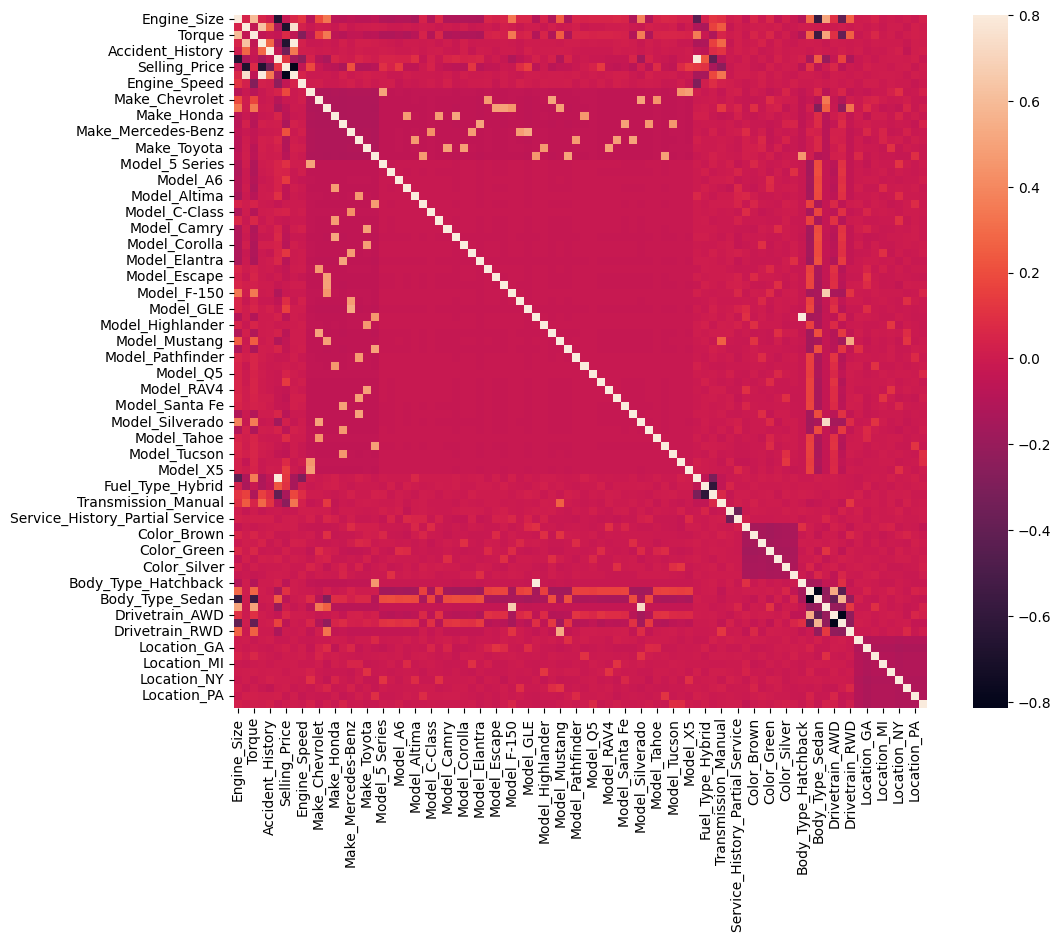

In [54]:
df_copy = pd.get_dummies(df, columns=categorial_features, drop_first=True)
corrmat = df_copy.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)

Проверим корелляцию между категориальными признаками после one hot encoding

<Axes: >

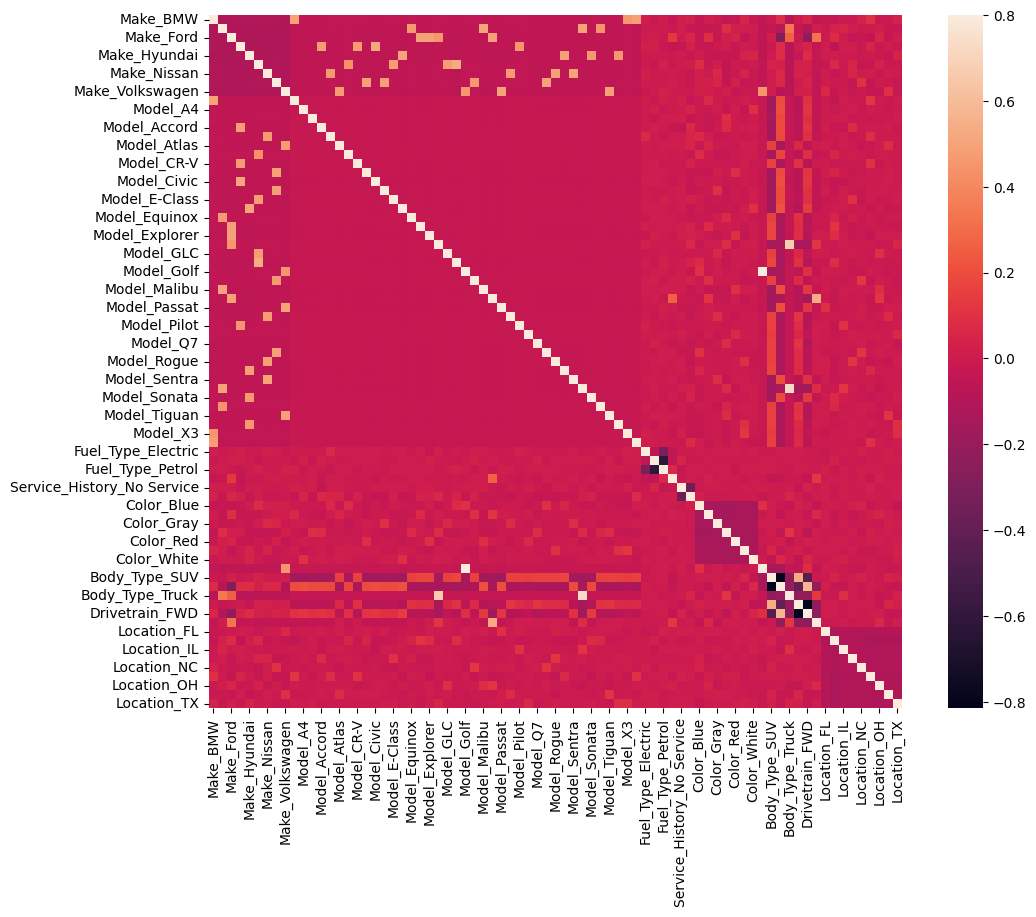

In [55]:
df_copy = pd.get_dummies(df[categorial_features], columns=categorial_features, drop_first=True)
corrmat = df_copy.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)

##4.1 Числовые признаки

<Axes: >

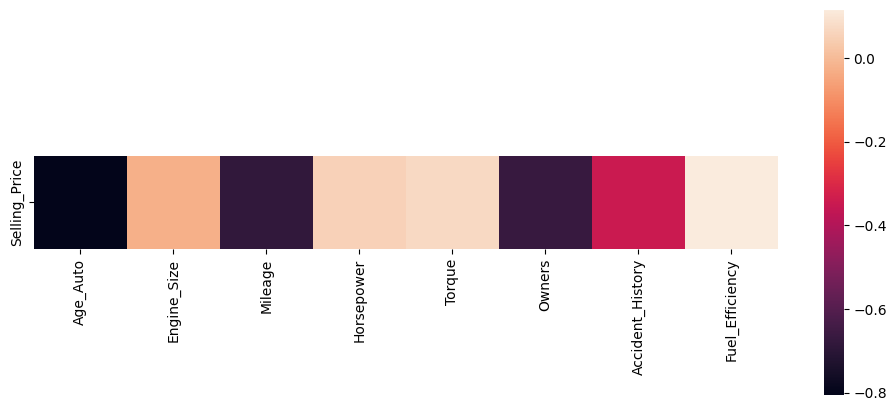

In [ ]:
correlation_price = df[number_features].corrwith(df['Selling_Price']).to_frame('Selling_Price').transpose()
f, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(correlation_price, square=True)

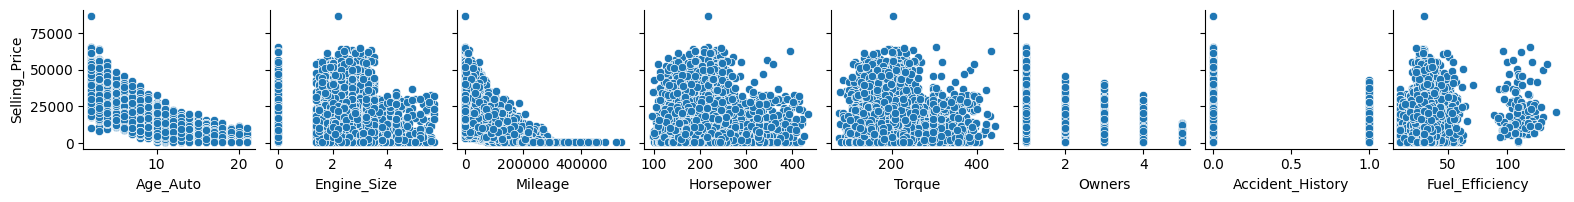

In [ ]:
sns.pairplot(df[number_features+[target_feature]], x_vars=number_features, y_vars = target_feature, height = 2 ,kind ='scatter',diag_kind='kde')
plt.show()

In [ ]:
df[number_features].corrwith(df['Selling_Price']).sort_values(ascending=False)

,0
Fuel_Efficiency,0.115462
Torque,0.070912
Horsepower,0.054210
Engine_Size,-0.026679
Accident_History,-0.347294
Owners,-0.669046
Mileage,-0.682883
Age_Auto,-0.804933


Можно сделать выводы, что и до заполнения пропусков: цена зависит от года выпуска, размера двигателя, пробега, количества владельцев, наличие аварий. Причем с ростом года растет цена, с размером двигателя цена падает, с увеличением пробега уена падает, с увеличением количества владельцев цена падает, с наличинем аварий цена падает.
Оставгиеся характеристики (размер двигателя, потрбелнеи топлива, лошадиные силы) не влияют на цену значительно.



##4.2 Категориальные признаки

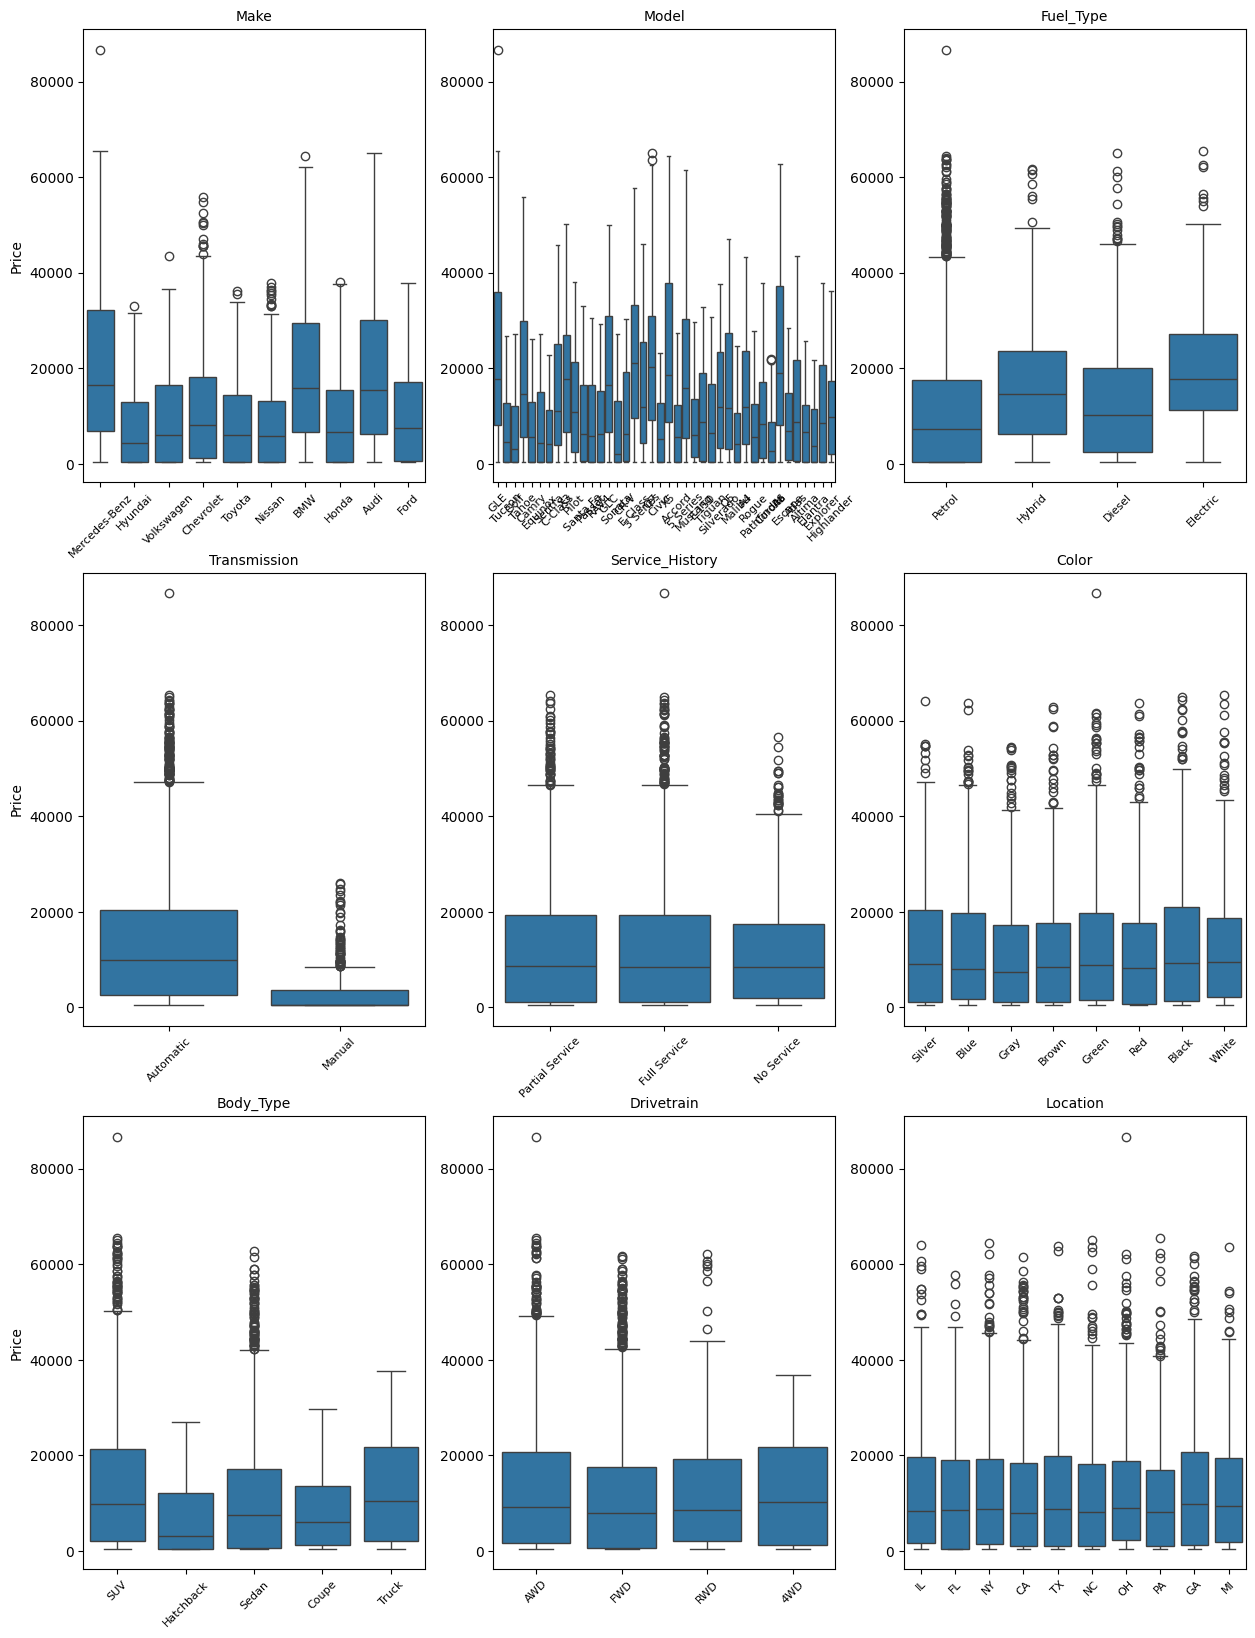

In [ ]:
cat_cols = categorial_features
# Создаём сетку 3x3
fig, axes = plt.subplots(3, 3, figsize=(15, 20))  # 3 строки, 3 колонки
axes = axes.flatten()  # превращаем в одномерный массив для удобства

# Рисуем графики
for i, col in enumerate(cat_cols):
    sns.boxplot(x=df[col], y=df['Selling_Price'], ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].set_ylabel('Price' if i % 3 == 0 else '')  # убираем повторяющиеся подписи
    axes[i].set_xlabel('')

<BarContainer object of 8 artists>

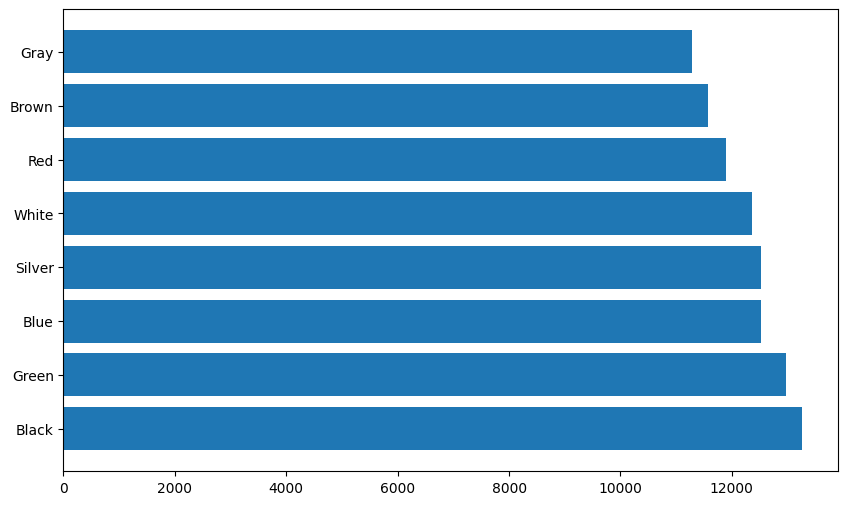

In [ ]:

color_categories = df.groupby('Color')['Selling_Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(color_categories.index, color_categories.values)

In [ ]:
drivetrain_categories = df.groupby('Drivetrain')['Selling_Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(drivetrain_categories.index, drivetrain_categories.values)

In [ ]:
location_categories = df.groupby('Location')['Selling_Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(location_categories.index, location_categories.values)

Можно сделать выводы, как и до заполнения пропусков: на цену влияет тип топлива, коробка передач, истории сервиса, марка машины. Незначительно на цену влияют цвет и локация, трансмиссия (drivetrain)

#5 Обучение линейной регрессии для подтверждения или опровержения выводов о влиянии признаков

В предыдущих разделах было установлено, какие признаки максимально влияют на цену автомобиля. Обучим модель линейной регрессии предсказывать стоимость авто, и по результатм оценим коэффициенты у признаков, влияют ли выявленные аналитически признаки на цену или нет с помощью R^2

In [ ]:
x = df[categorial_features + number_features]
#x.drop(columns=['Selling_Price'])
y = df[target_feature]

Рассмотрим распределение цены

<Axes: xlabel='Selling_Price', ylabel='Count'>

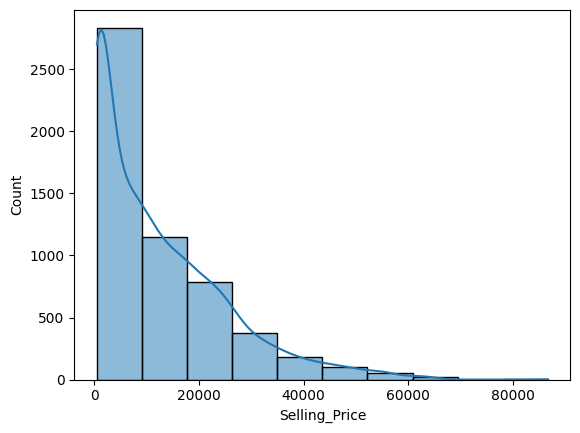

In [ ]:
sns.histplot(y, bins=10, kde=True)

Оно очень сильно отличается от нормального распределния, есть "перекосы". Линейная модель плохо работает с данными с "перекосами", с большой разницей в значениях, поэтому лучше столбец целевой переменной прологарифмировать, сделать разницу между значениями меньше

In [ ]:
y = np.log(y)

<Axes: xlabel='Selling_Price', ylabel='Count'>

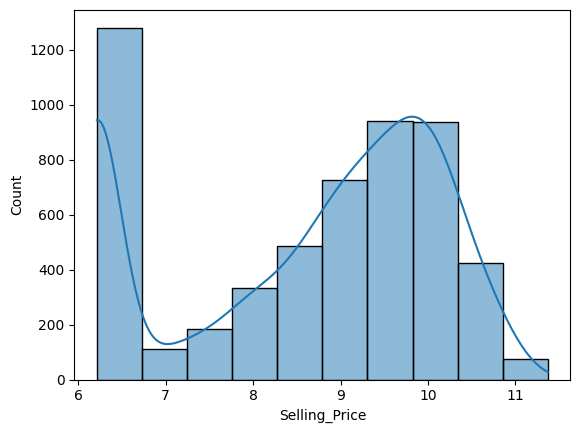

In [ ]:
sns.histplot(y, bins=10, kde=True)

#5.2 Кодирование категориальных переменных

Многие модели машинного обучения не могут напрямую работать с категориальными признаками, поэтому превращаем их в наборы числовых с помощью one-hot-encoding

In [ ]:
x[categorial_features].nunique()

,0
Make,10
Model,40
Fuel_Type,4
Transmission,2
Service_History,3
Color,8
Body_Type,5
Drivetrain,4
Location,10


Много видов моделей. Сгруппируем виды в группы, так сможем избежать корелляии и большого количества признаков

In [ ]:
x = pd.get_dummies(x, columns=categorial_features, drop_first=True)

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 85 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age_Auto                         5500 non-null   int64  
 1   Engine_Size                      5500 non-null   float64
 2   Mileage                          5500 non-null   int64  
 3   Horsepower                       5500 non-null   float64
 4   Torque                           5500 non-null   float64
 5   Owners                           5500 non-null   int64  
 6   Accident_History                 5500 non-null   float64
 7   Fuel_Efficiency                  5500 non-null   float64
 8   Make_BMW                         5500 non-null   bool   
 9   Make_Chevrolet                   5500 non-null   bool   
 10  Make_Ford                        5500 non-null   bool   
 11  Make_Honda                       5500 non-null   bool   
 12  Make_Hyundai        

Проверим корелляцию признаков друг с другом

<Axes: >

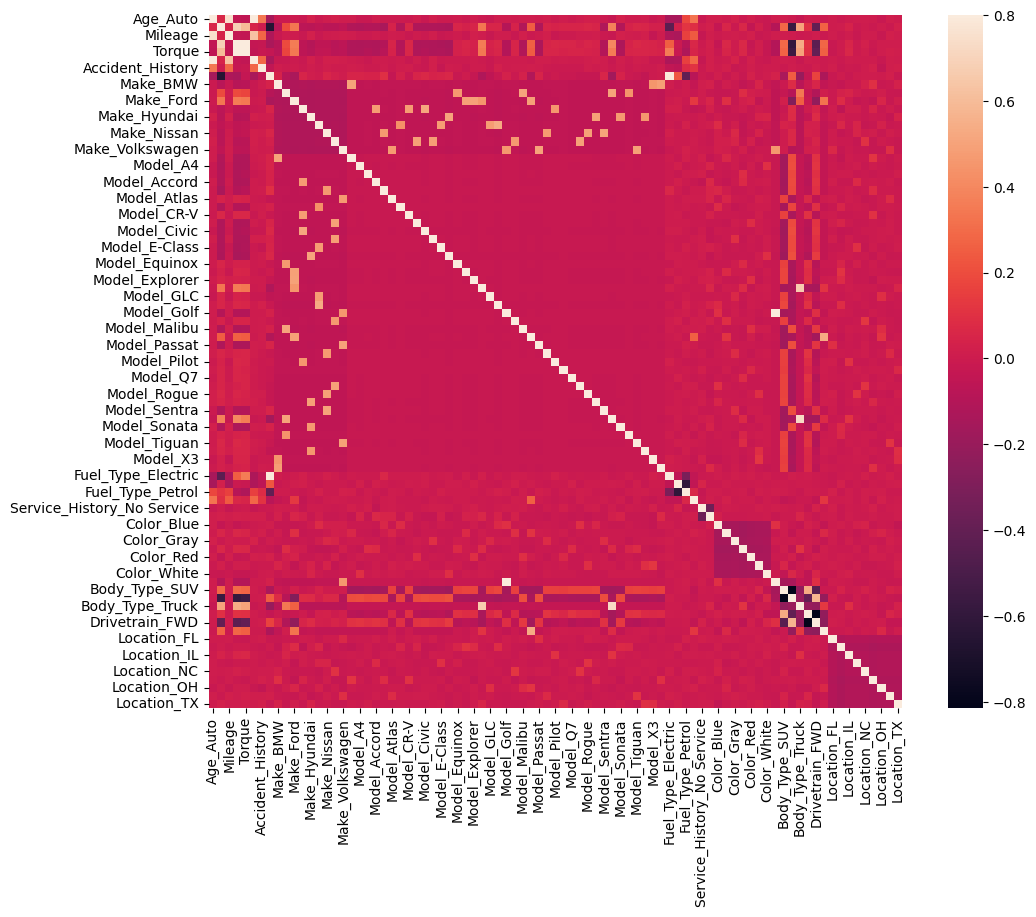

In [ ]:
corrmat = x.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)

<Axes: >

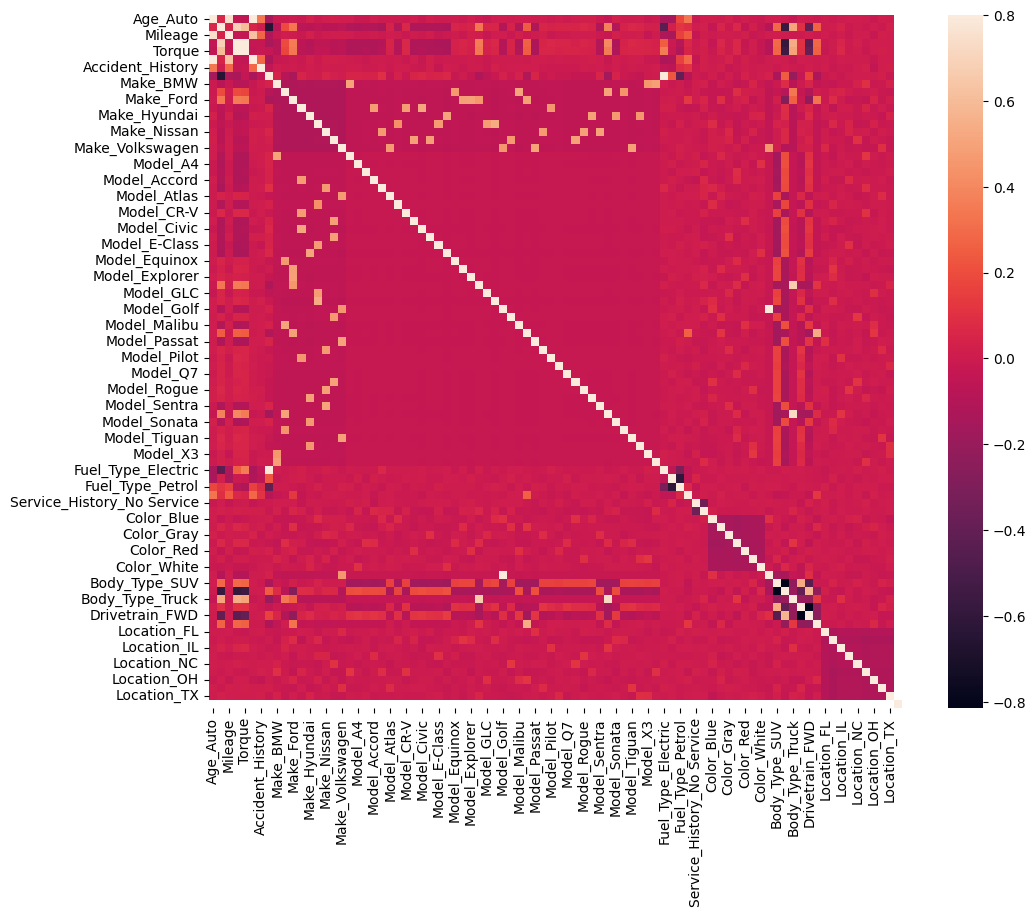

In [ ]:

corrmat = all.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)

In [ ]:
corrmat

#5.3 Разделение выборки на обучающую и тестовую

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


## 5.4 масштабирование признаков

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

5.5 Создание модели и обучение

In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')

Проверим результаты на обученной модели

In [ ]:
print(f"R² на кросс-валидации: {scores.mean():.3f} (+/- {scores.std() * 2:.3f})")

R² на кросс-валидации: 0.914 (+/- 0.006)


На тестовых данных

In [ ]:
y_pred_log = model.predict(X_test_scaled)

# Метрики в логарифмах
print(f"\nR² на тесте (log): {r2_score(y_test, y_pred_log):.3f}")
print(f"RMSE (log): {np.sqrt(mean_squared_error(y_test, y_pred_log)):.3f}")

# Метрики в деньгах
y_test_orig = np.exp(y_test)
y_pred_orig = np.exp(y_pred_log)

print(f"\nMAE: {mean_absolute_error(y_test_orig, y_pred_orig):.0f} $")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_orig, y_pred_orig)):.0f} $")


R² на тесте (log): 0.910
RMSE (log): 0.457

MAE: 3801 $
RMSE: 8845 $


In [ ]:
coef_df = pd.DataFrame({
    'Attribute': x.columns,
    'Influence': model.coef_
})


coef_df['Influence_Abs'] = coef_df['Influence'].abs()


coef_df_sorted = coef_df.sort_values('Influence_Abs', ascending=False)

coef_df_sorted

,Attribute,Influence,Influence_Abs
0,Age_Auto,-0.738477,0.738477
2,Mileage,-0.663002,0.663002
19,Model_A6,0.119364,0.119364
8,Make_BMW,0.119192,0.119192
44,Model_Q7,0.116777,0.116777
...,...,...,...
72,Body_Type_Truck,0.002371,0.002371
75,Drivetrain_RWD,0.001959,0.001959
32,Model_Explorer,-0.001562,0.001562
82,Location_OH,0.000354,0.000354


In [ ]:
# R² на трейне
y_train_pred = model.predict(X_train_scaled)
r2_train = r2_score(y_train, y_train_pred)

# R² на тесте
r2_test = r2_score(y_test, y_pred_log)

print(f"R² на трейне: {r2_train:.4f}")
print(f"R² на тесте:  {r2_test:.4f}")
print(f"Разница:     {r2_train - r2_test:.4f}")

R² на трейне: 0.9171
R² на тесте:  0.9102
Разница:     0.0069


#6 Выводы